In [1]:
!pip install scikit-learn
!pip install tensorflow
!pip install setuptools

In [2]:
%pip install keras-tuner

import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
import numpy as np
import time
import matplotlib.pyplot as plt
from datetime import datetime
import os

Note: you may need to restart the kernel to use updated packages.


Enable / Disable Hyperparameter Tuning

In [3]:
HYPERPARAMETER_TUNING = False

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

# Data Loading

In [5]:
raw_df = pd.read_csv('../data/data.csv', parse_dates=['timestamp'])
primary_service = raw_df['service_id'].mode()[0]
df_pods = raw_df[raw_df['service_id'] == primary_service].copy()
df_pods = df_pods.sort_values('timestamp').drop_duplicates(subset='timestamp')
df_pods.rename(columns={'timestamp': 'ds', 'current_pod_count': 'pod_count'}, inplace=True)
feature_cols = [c for c in df_pods.columns if c not in ['ds', 'service_id', 'pod_count']]

print(f'Using service: {primary_service}')
print(f'Dataset length: {len(df_pods)} | Feature count: {len(feature_cols)}')
print(f'Features: {feature_cols}')
df_pods[['ds', 'pod_count']].head()

Using service: Order
Dataset length: 43200 | Feature count: 20
Features: ['request_rate_rps', 'latency_p95_ms', 'latency_p99_ms', 'error_rate_percent', 'queue_length', 'pod_cpu_usage_percent_avg', 'pod_cpu_usage_percent_p95', 'pod_memory_usage_mb_avg', 'pod_memory_usage_mb_p95', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'mesh_inbound_rps', 'mesh_inbound_latency_p95', 'mesh_inbound_error_rate', 'degree_centrality', 'eigenvector_centrality', 'betweenness_centrality', 'closeness_centrality']


,ds,pod_count
0,2025-11-01 00:00:00,2
1,2025-11-01 00:01:00,2
2,2025-11-01 00:02:00,2
3,2025-11-01 00:03:00,2
4,2025-11-01 00:04:00,2


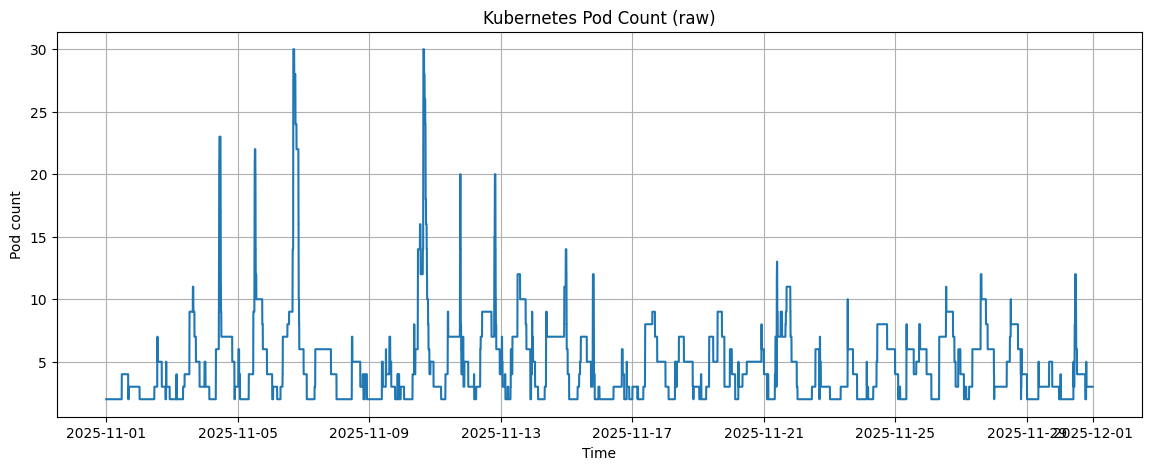

In [6]:
# Ensure images directory exists before saving plots
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(14, 5))
plt.plot(df_pods['ds'], df_pods['pod_count'])
plt.title('Kubernetes Pod Count (raw)')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.savefig("images/bilstm-pods-raw.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Data Splitting & Preprocessing

1. Scale pod count and features to 0-1
2. Split dataset as 70% training, 30% testing (time-ordered)
3. Forward-fill missing values
4. Drop duplicate timestamps

In [7]:
target_scaler = MinMaxScaler(feature_range=(0, 1))
feature_scaler = MinMaxScaler()

df_pods['y'] = target_scaler.fit_transform(df_pods[['pod_count']])
df_pods[feature_cols] = feature_scaler.fit_transform(df_pods[feature_cols])

In [8]:
train_df_pods, test_df_pods = train_test_split(df_pods, test_size=0.3, random_state=42, shuffle=False)

print(f'POD DATASET: Train Set: {train_df_pods.shape} | Test Set: {test_df_pods.shape}')

POD DATASET: Train Set: (30240, 24) | Test Set: (12960, 24)


In [9]:
train_df_pods['y'].fillna(method='ffill', inplace=True)
train_df_pods.drop_duplicates(subset='ds', inplace=True)

print(f'POD DATASET: Train Set: {train_df_pods.shape} | Test Set: {test_df_pods.shape}')

POD DATASET: Train Set: (30240, 24) | Test Set: (12960, 24)


C:\Users\dilee\AppData\Local\Temp\ipykernel_32160\4286280144.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_pods['y'].fillna(method='ffill', inplace=True)
C:\Users\dilee\AppData\Local\Temp\ipykernel_32160\4286280144.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df_pods['y'].fillna(method='ffill', inplace=True)


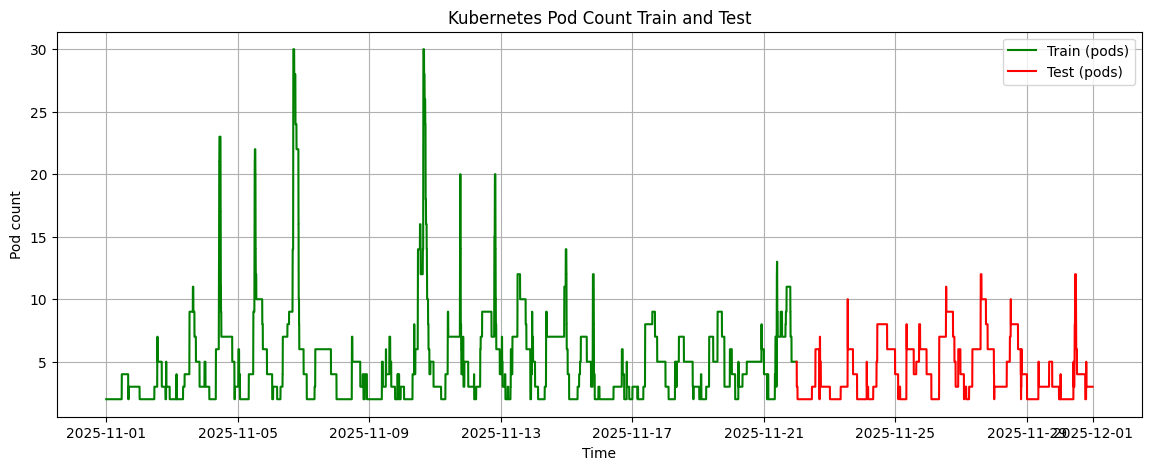

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(train_df_pods['ds'], train_df_pods['pod_count'], label='Train (pods)', color='green')
plt.plot(test_df_pods['ds'], test_df_pods['pod_count'], label='Test (pods)', color='red')
plt.title('Kubernetes Pod Count Train and Test')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.legend()
plt.savefig("images/bilstm-pods-train-test.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Model Training

## Prepare Dataset for Bi-LSTM

Create sliding window sequences with multivariate features for time-series prediction.

In [11]:
def create_dataset(features, target, look_back, horizon=5):
    """Create sliding window sequences for time-series prediction.

    Args:
        features: DataFrame or array of input features
        target: Array of target values
        look_back: Number of time steps to look back
        horizon: Number of time steps ahead to predict

    Returns:
        X: 3D array of shape (samples, look_back, features)
        y: 1D array of target values
    """
    X, y = [], []
    features = np.array(features)
    target = np.array(target)
    max_start = len(target) - look_back - horizon + 1
    for i in range(max_start):
        X.append(features[i:i + look_back, :])
        y.append(target[i + look_back + horizon - 1])
    return np.array(X), np.array(y)

In [12]:
# Sliding window size (look_back)
look_back = 48
horizon = 5  # 5-minute forecast horizon

# Use all features + target for multivariate input
input_feature_cols = feature_cols + ['y']

X_pods, y_pods = create_dataset(df_pods[input_feature_cols], df_pods['y'], look_back, horizon=horizon)

print(f'Input shape: {X_pods.shape}')
print(f'Target shape: {y_pods.shape}')
print(f'Look-back: {look_back} | Horizon: {horizon}')

Input shape: (43148, 48, 21)
Target shape: (43148,)
Look-back: 48 | Horizon: 5


In [13]:
X_train_pods, X_test_pods, y_train_pods, y_test_pods = train_test_split(
    X_pods, y_pods, test_size=0.3, random_state=42, shuffle=False
)

num_features = X_train_pods.shape[2]

print(f'POD DATASET: Train Set: {X_train_pods.shape} | Test Set: {X_test_pods.shape}')
print(f'Number of features: {num_features}')

POD DATASET: Train Set: (30203, 48, 21) | Test Set: (12945, 48, 21)
Number of features: 21


## Model Definition

In [14]:
model = None

### Callbacks

In [15]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

### HyperParameter Tuning (If Enabled)

In [16]:
def build_model(hp):
    model = Sequential()
    
    # First Bidirectional LSTM layer
    model.add(Bidirectional(
        LSTM(
            units=hp.Int('units_1', min_value=32, max_value=256, step=32),
            return_sequences=True
        ),
        input_shape=(look_back, num_features)
    ))
    model.add(Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))
    
    # Second Bidirectional LSTM layer
    model.add(Bidirectional(
        LSTM(
            units=hp.Int('units_2', min_value=32, max_value=256, step=32),
            return_sequences=False
        )
    ))
    model.add(Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))
    
    # Dense layers
    model.add(Dense(hp.Int('dense_units', min_value=16, max_value=128, step=16), activation='relu'))
    model.add(Dense(1))
    
    model.compile(
        optimizer=hp.Choice('optimizer', values=['adam', 'rmsprop']),
        loss='mean_squared_error'
    )
    return model

In [17]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=2,
    directory='hyperparam_tuning',
    project_name='bilstm_hyperparam_tuning'
)

c:\Users\dilee\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
if HYPERPARAMETER_TUNING:
    tuner.search(
        X_train_pods, y_train_pods,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

In [19]:
if HYPERPARAMETER_TUNING:
    model = tuner.get_best_models(num_models=1)[0]
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"Units Layer 1: {best_hp.get('units_1')}")
    print(f"Units Layer 2: {best_hp.get('units_2')}")
    print(f"Dropout 1: {best_hp.get('dropout_1')}")
    print(f"Dropout 2: {best_hp.get('dropout_2')}")
    print(f"Dense Units: {best_hp.get('dense_units')}")
    print(f"Optimizer: {best_hp.get('optimizer')}")

### Default Model

In [20]:
if not HYPERPARAMETER_TUNING:
    model = Sequential([
        # First Bidirectional LSTM layer
        Bidirectional(
            LSTM(64, return_sequences=True),
            input_shape=(look_back, num_features)
        ),
        Dropout(0.2),
        
        # Second Bidirectional LSTM layer
        Bidirectional(
            LSTM(32, return_sequences=False)
        ),
        Dropout(0.2),
        
        # Dense layers
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mean_squared_error')

Print Model Summary

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 48, 128)        │        44,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,361 (341.25 KB)

 Trainable params: 87,361 (341.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [22]:
history = model.fit(
    X_train_pods, y_train_pods,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
756/756 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - loss: 0.0021 - val_loss: 5.1101e-04 - learning_rate: 0.0010
Epoch 2/50
756/756 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - loss: 8.6879e-04 - val_loss: 4.9588e-04 - learning_rate: 0.0010
Epoch 3/50
756/756 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - loss: 6.9814e-04 - val_loss: 4.2396e-04 - learning_rate: 0.0010
Epoch 4/50
756/756 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - loss: 6.6566e-04 - val_loss: 3.5403e-04 - learning_rate: 0.0010
Epoch 5/50
756/756 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - loss: 6.4868e-04 - val_loss: 3.8599e-04 - learning_rate: 0.0010
Epoch 6/50
756/756 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - loss: 5.8481e-04 - val_loss: 3.4391e-04 - learning_rate: 0.0010
Epoch 7/50
756/756 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - loss: 5.7531e-04 - val_loss: 3.3010e-04 - learning_rate: 0.0010
Epoch 8/50
756/756 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - loss: 5.3522e-04 - val_loss: 3.0384e-04 - learning_rate: 0.0010
Epoch 9/50
755/756 ━━━━━━━━━━━━━━━━━━━━ 0s 3

### Training History

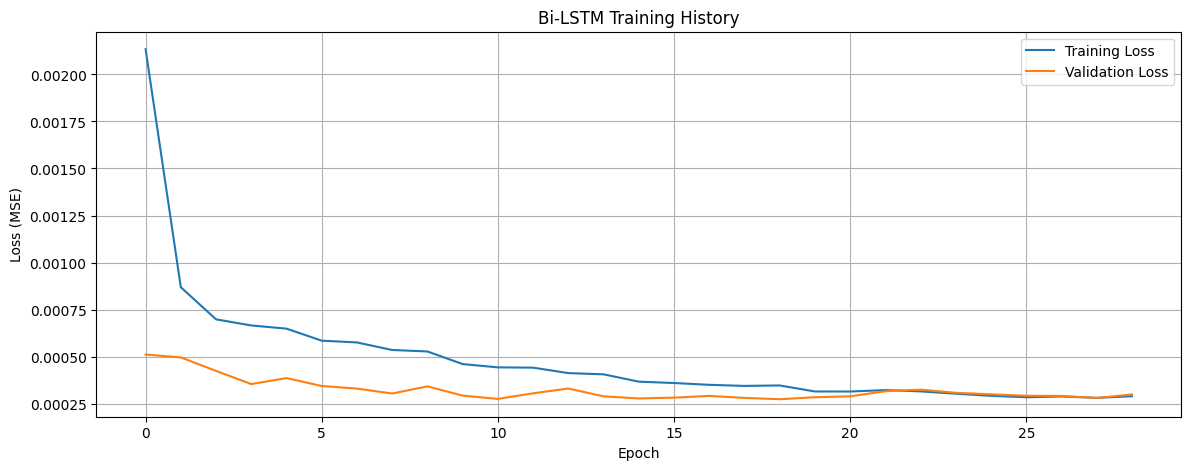

In [23]:
plt.figure(figsize=(14, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Bi-LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.savefig("images/bilstm-training-history.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Predict Dataset

In [24]:
pods_train_predict = model.predict(X_train_pods)

start_time = time.time()
pods_test_predict = model.predict(X_test_pods)
end_time = time.time()

prediction_time = (end_time - start_time) * 1000

print(f'POD DATASET - Prediction Size Train: {len(pods_train_predict)} | Prediction Size Test: {len(pods_test_predict)}')
print(f'Prediction Time: {prediction_time:.2f}ms')

944/944 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
POD DATASET - Prediction Size Train: 30203 | Prediction Size Test: 12945
Prediction Time: 4647.71ms


## Evaluate Model (Scaled Values)

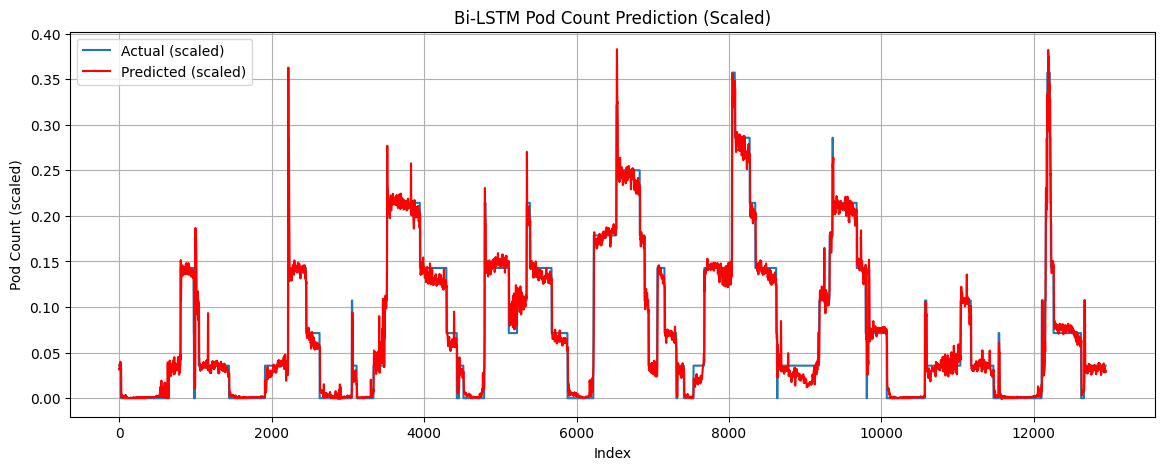

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_pods, label='Actual (scaled)', color='#1f77b4')
plt.plot(pods_test_predict, label='Predicted (scaled)', color='red')
plt.xlabel('Index')
plt.ylabel('Pod Count (scaled)')
plt.title('Bi-LSTM Pod Count Prediction (Scaled)')
plt.legend()
plt.grid(True)
plt.savefig("images/bilstm-pods-scaled-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [26]:
mse_scaled = mean_squared_error(y_test_pods, pods_test_predict)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_test_pods, pods_test_predict)
r2_scaled = r2_score(y_test_pods, pods_test_predict)

print('=== Bi-LSTM Model Metrics (Scaled Values) ===')
print(f'MSE: {mse_scaled:.6f}')
print(f'RMSE: {rmse_scaled:.6f}')
print(f'MAE: {mae_scaled:.6f}')
print(f'R²: {r2_scaled:.6f}')

=== Bi-LSTM Model Metrics (Scaled Values) ===
MSE: 0.000189
RMSE: 0.013734
MAE: 0.007431
R²: 0.970697


## Inverse Transform & Final Evaluation

In [27]:
# Inverse transform predictions to original scale
y_test_actual = target_scaler.inverse_transform(y_test_pods.reshape(-1, 1)).flatten()
y_test_predicted = target_scaler.inverse_transform(pods_test_predict).flatten()

# Round to nearest integer (pod count should be whole numbers)
y_test_predicted_rounded = np.round(y_test_predicted).astype(int)
y_test_predicted_rounded = np.maximum(y_test_predicted_rounded, 1)  # Minimum 1 pod

print(f'Actual pods range: {y_test_actual.min():.0f} - {y_test_actual.max():.0f}')
print(f'Predicted pods range: {y_test_predicted_rounded.min()} - {y_test_predicted_rounded.max()}')

Actual pods range: 2 - 12
Predicted pods range: 2 - 13


In [28]:
mse = mean_squared_error(y_test_actual, y_test_predicted_rounded)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_test_predicted_rounded)
r2 = r2_score(y_test_actual, y_test_predicted_rounded)

print('=== Bi-LSTM Model Metrics (Pod Count) ===')
print(f'MSE: {mse:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'MAE: {mae:.6f}')
print(f'R²: {r2:.6f}')
print(f'Prediction Time: {prediction_time:.2f}ms')

=== Bi-LSTM Model Metrics (Pod Count) ===
MSE: 0.152569
RMSE: 0.390600
MAE: 0.102047
R²: 0.969770
Prediction Time: 4647.71ms


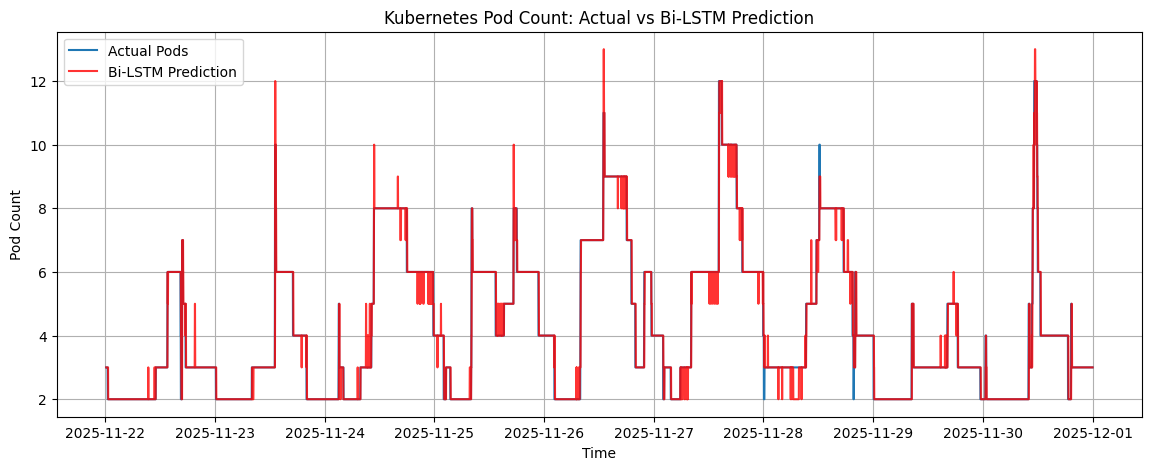

In [29]:
# Get corresponding timestamps for test set
start_idx = len(X_train_pods) + look_back + horizon - 1
test_timestamps = df_pods['ds'].iloc[start_idx:start_idx + len(y_test_pods)].values

plt.figure(figsize=(14, 5))
plt.plot(test_timestamps, y_test_actual, label='Actual Pods', color='#1f77b4', linewidth=1.5)
plt.plot(test_timestamps, y_test_predicted_rounded, label='Bi-LSTM Prediction', color='red', linewidth=1.5, alpha=0.8)
plt.title('Kubernetes Pod Count: Actual vs Bi-LSTM Prediction')
plt.xlabel('Time')
plt.ylabel('Pod Count')
plt.grid(True)
plt.legend()
plt.savefig("images/bilstm-pods-final-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

### Zoomed View (First 1000 samples)

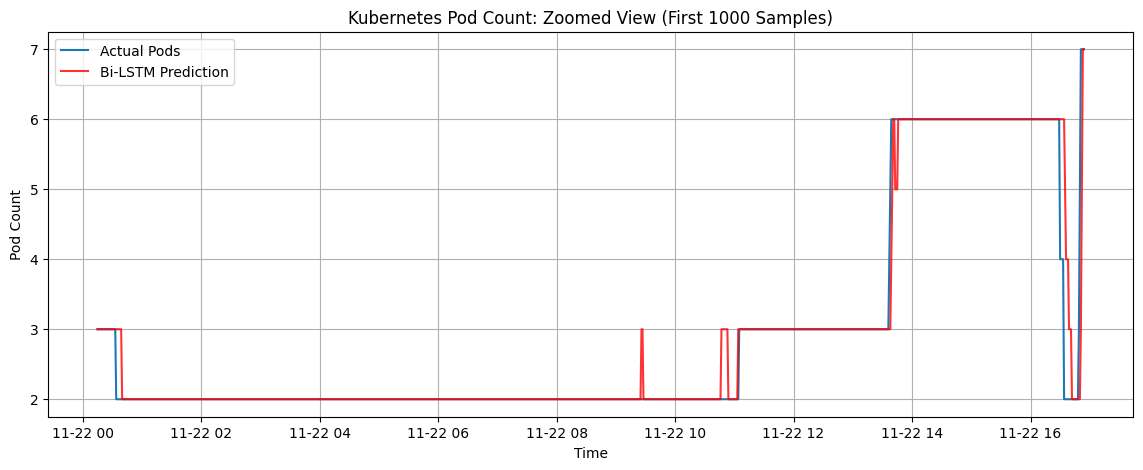

In [30]:
zoom_samples = 1000

plt.figure(figsize=(14, 5))
plt.plot(test_timestamps[:zoom_samples], y_test_actual[:zoom_samples], label='Actual Pods', color='#1f77b4', linewidth=1.5)
plt.plot(test_timestamps[:zoom_samples], y_test_predicted_rounded[:zoom_samples], label='Bi-LSTM Prediction', color='red', linewidth=1.5, alpha=0.8)
plt.title('Kubernetes Pod Count: Zoomed View (First 1000 Samples)')
plt.xlabel('Time')
plt.ylabel('Pod Count')
plt.grid(True)
plt.legend()
plt.savefig("images/bilstm-pods-zoomed.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Error Analysis

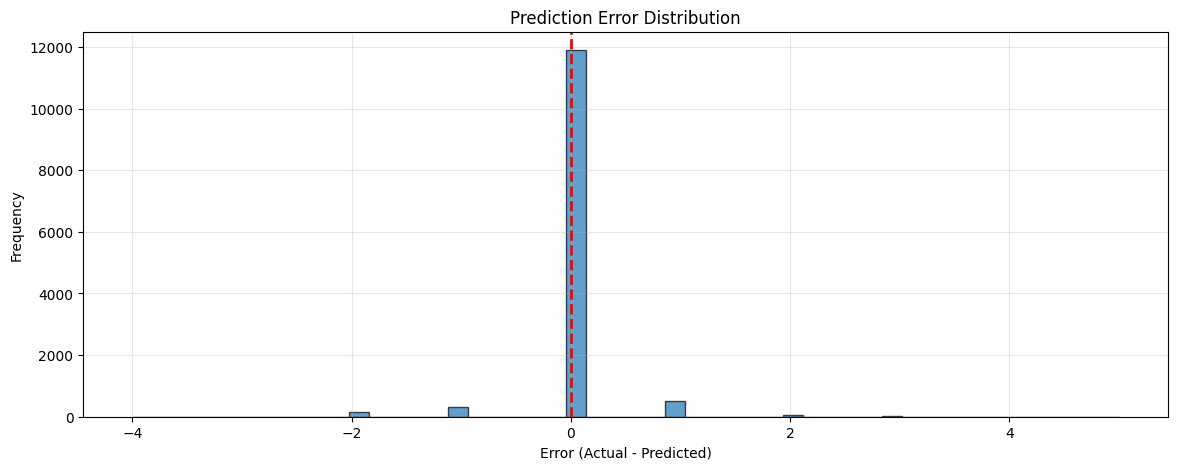

Mean Error: 0.0038
Std Error: 0.3906
Max Over-prediction: -4.0
Max Under-prediction: 5.0


In [31]:
errors = y_test_actual - y_test_predicted_rounded

plt.figure(figsize=(14, 5))
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.title('Prediction Error Distribution')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.savefig("images/bilstm-error-distribution.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

print(f'Mean Error: {errors.mean():.4f}')
print(f'Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.min()}')
print(f'Max Under-prediction: {errors.max()}')

In [32]:
# Under-provisioning and Over-provisioning analysis
under_provisioned = (y_test_predicted_rounded < y_test_actual).sum()
over_provisioned = (y_test_predicted_rounded > y_test_actual).sum()
exact_match = (y_test_predicted_rounded == y_test_actual).sum()

total = len(y_test_actual)

print('=== Provisioning Analysis ===')
print(f'Under-provisioned: {under_provisioned} ({100*under_provisioned/total:.2f}%)')
print(f'Over-provisioned: {over_provisioned} ({100*over_provisioned/total:.2f}%)')
print(f'Exact match: {exact_match} ({100*exact_match/total:.2f}%)')

=== Provisioning Analysis ===
Under-provisioned: 575 (4.44%)
Over-provisioned: 502 (3.88%)
Exact match: 11868 (91.68%)


## Save Model

In [33]:
os.makedirs('models', exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save model
model_filename = f'models/bilstm-pods-{timestamp}.keras'
model.save(model_filename)
print(f'Model saved: {model_filename}')

# Save scalers
import joblib
scaler_filename = f'models/bilstm-scalers-{timestamp}.pkl'
joblib.dump({'target_scaler': target_scaler, 'feature_scaler': feature_scaler}, scaler_filename)
print(f'Scalers saved: {scaler_filename}')

Model saved: models/bilstm-pods-20260104_012142.keras
Scalers saved: models/bilstm-scalers-20260104_012142.pkl


## Summary

In [34]:
print('=' * 60)
print('BI-LSTM MODEL SUMMARY')
print('=' * 60)
print(f'Dataset: data.csv ({primary_service})')
print(f'Total samples: {len(df_pods)}')
print(f'Features: {num_features} (multivariate)')
print(f'Look-back window: {look_back}')
print(f'Forecast horizon: {horizon} minutes')
print(f'Train/Test split: 70/30')
print('-' * 60)
print('METRICS (Pod Count)')
print('-' * 60)
print(f'MSE: {mse:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'MAE: {mae:.6f}')
print(f'R²: {r2:.6f}')
print('-' * 60)
print('PROVISIONING')
print('-' * 60)
print(f'Under-provisioned: {100*under_provisioned/total:.2f}%')
print(f'Over-provisioned: {100*over_provisioned/total:.2f}%')
print(f'Exact match: {100*exact_match/total:.2f}%')
print('-' * 60)
print(f'Prediction Time: {prediction_time:.2f}ms')
print('=' * 60)

BI-LSTM MODEL SUMMARY
Dataset: data.csv (Order)
Total samples: 43200
Features: 21 (multivariate)
Look-back window: 48
Forecast horizon: 5 minutes
Train/Test split: 70/30
------------------------------------------------------------
METRICS (Pod Count)
------------------------------------------------------------
MSE: 0.152569
RMSE: 0.390600
MAE: 0.102047
R²: 0.969770
------------------------------------------------------------
PROVISIONING
------------------------------------------------------------
Under-provisioned: 4.44%
Over-provisioned: 3.88%
Exact match: 91.68%
------------------------------------------------------------
Prediction Time: 4647.71ms
